In [1]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [2]:
mnist_dataset, mnist_info = tfds.load(name="mnist", as_supervised=True, with_info=True)
mnist_train, mnist_test = mnist_dataset["train"], mnist_dataset["test"]
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.N7YKJC_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.N7YKJC_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [4]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [5]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)


(6000, 28, 28, 1) (6000,)


In [6]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8840 - loss: 0.4141 - val_accuracy: 0.9393 - val_loss: 0.2062
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9477 - loss: 0.1808 - val_accuracy: 0.9545 - val_loss: 0.1617
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9588 - loss: 0.1405 - val_accuracy: 0.9590 - val_loss: 0.1431
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9658 - loss: 0.1157 - val_accuracy: 0.9617 - val_loss: 0.1305
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9711 - loss: 0.0968 - val_accuracy: 0.9598 - val_loss: 0.1314
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9749 - loss: 0.0838 - val_accuracy: 0.9667 - val_loss: 0.1125
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9784 - loss: 0.0721 - val_accuracy: 0.9690 - val_loss: 0.1104
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9809 - loss: 0.0647 - val_accuracy: 

In [8]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%' .format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step - accuracy: 0.9686 - loss: 0.1132
Test loss: 0.11. Test accuracy: 96.86%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prawdopodobieństwa dla klas od 0 do 9:
[[4.2863951e-19 9.8816851e-24 2.9284262e-18 1.3556453e-11 5.5081168e-37
  1.0000000e+00 3.3321666e-19 2.6469738e-08 1.0996032e-27 5.2696218e-19]]

ROZPOZNANA CYFRA TO: 5 



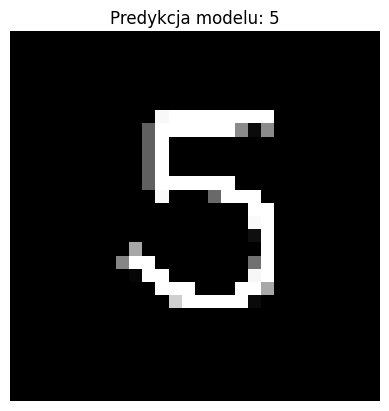

In [12]:
image_path = 'sample_data/cyfra.png'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is not None:
    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0

    img_ready = np.expand_dims(img_normalized, axis=0)
    img_ready = np.expand_dims(img_ready, axis=-1)

    predictions = model.predict(img_ready)

    predicted_digit = np.argmax(predictions)

    print(f"Prawdopodobieństwa dla klas od 0 do 9:\n{predictions}")
    print(f"\nROZPOZNANA CYFRA TO: {predicted_digit} \n")

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predykcja modelu: {predicted_digit}")
    plt.axis('off')
    plt.show()
else:
    print(f"Nie znaleziono pliku '{image_path}'.")